# yy12 — Demo: linking features across modalities via the common schema

*Provenance: Ported from yy11_01_big_vis (demos 1, 4, 5, 7) and yy11_03_cellToCell (demo 5). Helpers copied verbatim from those notebooks.*

We want to show features that only exist in some modalities and then link cells across modalities using either common features or common cluster labels. This notebook is an early look at what those visualizations can look like — enough to get feedback from colleagues on what's working and what needs rethinking.

## How to read this notebook

- **Section 1** — Schema primer: the three concepts we actually use (cells, features, clusters), plus a brief mention of cell-to-cell mapping.
- **Section 2** — Data loading: each table is loaded and previewed (shape + first 3 rows) so you can see its columns at a glance.
- **Section 3** — Five demos, each making one specific visual point about cross-modal linking.
- **Section 4** — Open questions I want the group's input on.


## Part 1 — Schema primer

The demo uses three schema concepts from the common connectivity schema. You don't need to understand the full schema — just these three.

**1. Cells → `DataItem`**  
An individual cell (or any atomic datum). Every cell has an `id` and belongs to a `DataSet` (e.g. `minnie65`, `patchseq_visp`, `wnm`). Defined in `schemas/core_schema.yaml`.

**2. Features → `CellFeatureSet` / `CellFeatureDefinition` / `CellFeatureMatrix`**  
A `CellFeatureSet` is a named collection of features (e.g. "minnie exc skeleton keys", "patchseq morph features", "csm cluster features"). Each feature is a `CellFeatureDefinition` (name, unit, dtype, range). A `CellFeatureMatrix` is the wide parquet table with one row per `DataItem` and one column per feature. Defined in `schemas/cell_features_schema.yaml`.

**3. Clusters → `Cluster` / `ClusterHierarchy` / `ClusterMembership` / `CellToClusterMapping`**  
A taxonomy is a `ClusterHierarchy` made of `Cluster` nodes (CSM minnie65, visp_met_types, tasic_2018_visp_scrnaseq T-types). A cell gets attached to a cluster either via `ClusterMembership` (when the cluster lives in the same dataset) or `CellToClusterMapping` (when it was transferred from another dataset). Defined in `schemas/clustering_schema.yaml` and `schemas/mappings_schema.yaml`.

The pattern is **cells → features → clusters**: the common schema lets us pull a feature column from one modality and place it next to a taxonomy column from another — as long as both are anchored to the same cell IDs. This is what makes cross-modal comparison tractable without manually re-indexing tables.

| Concept | LinkML class(es) | Schema file |
|---|---|---|
| Cell | `DataItem`, `DataSet` | `core_schema.yaml` |
| Feature | `CellFeatureSet`, `CellFeatureDefinition`, `CellFeatureMatrix` | `cell_features_schema.yaml` |
| Cluster / taxonomy | `Cluster`, `ClusterHierarchy`, `ClusterMembership`, `CellToClusterMapping` | `clustering_schema.yaml`, `mappings_schema.yaml` |
| Cell-to-cell link | `CellToCellMapping` | `mappings_schema.yaml` |

Cell-to-cell mapping is the fourth concept we use, sitting on top of features + clusters: it connects a source cell in one dataset to the k nearest cells in another dataset.


In [1]:
# --- Imports and path constants ---
import os
import polars as pl
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt

COMBINED_ROOT = "/scratch/combined_datasets"
H5AD_ROOT     = "/scratch/h5ad_outputs"


## Helper Functions

In [12]:
# --- Helpers (copied from yy11_01_big_vis and yy11_03_cellToCell, unchanged) ---
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import numpy as np


def get_leaf_type_df(
    table: str,
    filter_value: str,
    filter_col: str = "project_id",
    id_col: str | None = None,
    label_col: str | None = None,
    cluster_project_id: str | None = None,
    cast_id_to_int: bool = True,
) -> pd.DataFrame:
    """
    Load cell-to-type assignments from 'clustermembership' or 'celltoclustermapping',
    join the cluster hierarchy to find each cell's leaf-level (deepest) assignment,
    and return a tidy DataFrame with columns: id, predicted_label.

    Parameters
    ----------
    table : str
        Table name: 'clustermembership' or 'celltoclustermapping'.
    filter_value : str
        Value to filter on (e.g. project_id or mapping_set).
    filter_col : str
        Column to filter on (default 'project_id').
    id_col : str, optional
        Cell ID column. Auto-detected: 'item' for clustermembership, 'source_cell' otherwise.
    label_col : str, optional
        Label column. Auto-detected: 'cluster' or 'target_cluster'.
    cluster_project_id : str, optional
        Restrict cluster hierarchy lookup to this project_id.
    cast_id_to_int : bool
        Cast the id column to int64 (default True). Set False for WNM-style compound string IDs.

    Returns
    -------
    pd.DataFrame with columns ['id', 'predicted_label'].
    """
    if id_col is None:
        id_col = "item" if table == "clustermembership" else "source_cell"
    if label_col is None:
        label_col = "cluster" if table == "clustermembership" else "target_cluster"

    df = (
        pl.read_delta(os.path.join(COMBINED_ROOT, table))
        .filter(pl.col(filter_col) == filter_value)
        .select([id_col, label_col])
    )

    df_clusters = pl.read_delta(os.path.join(COMBINED_ROOT, "cluster"))
    if cluster_project_id:
        df_clusters = df_clusters.filter(pl.col("project_id") == cluster_project_id)

    result = (
        df
        .join(df_clusters.select(["id", "level"]), left_on=label_col, right_on="id", how="left")
        .sort("level", descending=True, nulls_last=True)
        .group_by(id_col)
        .first()
        .select([id_col, label_col])
        .rename({id_col: "id", label_col: "predicted_label"})
        .to_pandas()
    )

    if cast_id_to_int:
        result["id"] = result["id"].astype("int64")
    return result


def read_feats(sub_path: str, id_is_int: bool = True,
               project_id_filter: str | None = None) -> pd.DataFrame:
    """Read a cellfeatures delta table.
    Optionally filter to a specific project_id and cast id to int64.
    """
    df = pl.read_delta(os.path.join(COMBINED_ROOT, "cellfeatures", sub_path))
    if project_id_filter is not None:
        df = df.filter(pl.col("project_id") == project_id_filter)
    result = df.to_pandas()
    if id_is_int:
        result["id"] = result["id"].astype("int64")
    return result


def stretch_to_match(
    df_source: pd.DataFrame,
    df_target: pd.DataFrame,
    group_col: str,
) -> pd.DataFrame:
    """Resample *df_source* rows within each group to match *df_target* group counts.

    For each unique value of *group_col* in *df_target*, the corresponding rows in
    *df_source* are resampled (nearest-neighbour via np.linspace) to produce exactly
    as many rows as *df_target* has for that group.  Groups absent from *df_source*
    are silently skipped.  The returned DataFrame has the same group order as
    *df_target*.
    """
    parts = []
    seen: set = set()
    ordered_groups = [g for g in df_target[group_col]
                      if g not in seen and not seen.add(g)]  # type: ignore[func-returns-value]
    for group in ordered_groups:
        n_target = int((df_target[group_col] == group).sum())
        src_rows = df_source[df_source[group_col] == group]
        m = len(src_rows)
        if m == 0:
            continue
        idx = np.round(np.linspace(0, m - 1, n_target)).astype(int)
        parts.append(src_rows.iloc[idx].reset_index(drop=True))
    return pd.concat(parts, ignore_index=True)


def merge_strips(id_col: str, *specs) -> pd.DataFrame:
    """Inner-join several DataFrames on *id_col*, keeping only cells present in all.

    Each spec is one of:
        (df, [col1, col2, ...])                 – keep listed columns + id_col
        (df, [col1, ...], {'old': 'new', ...})  – also rename columns after selection

    Returns a single merged DataFrame.
    """
    result = None
    for spec in specs:
        df_in, cols = spec[0], spec[1]
        rename = spec[2] if len(spec) > 2 else {}
        keep = list({id_col} | set(cols))
        df_sel = df_in[keep].rename(columns=rename)
        result = df_sel if result is None else result.merge(df_sel, on=id_col, how="inner")
    return result.reset_index(drop=True)


def plot_strips(
    df: pd.DataFrame,
    features: list[dict] | None = None,
    labels: list[dict] | None = None,
    sort_by: list[str] | None = None,
    colorbar_position: str = "top",
    average_by=None,
    fig=None,
    strips: list[dict] | None = None,
) -> plt.Figure:
    """Plot a sorted cell-strip figure.

    Parameters
    ----------
    df : pd.DataFrame
        One row per cell.
    features : list of dict, optional
        Each dict: {'col': str, 'title': str, 'cmap': str}.
    labels : list of dict, optional
        Each dict: {'col': str, 'title': str, 'colors': dict[str, str]}.
    sort_by : list of str, optional
        Column names to sort rows by, in priority order.
    colorbar_position : 'top' | 'bottom'
    fig : matplotlib.figure.Figure or SubFigure, optional
    average_by : str or list of str, optional
        Column(s) to group by when averaging feature values.
    strips : list of dict, optional
        Ordered mixed list; each dict has type='feature'|'label'|'heatmap'.
        When provided, takes precedence over features and labels.

    Returns
    -------
    matplotlib.figure.Figure
    """
    if strips is not None:
        features = [dict({k: v for k, v in s.items() if k != "type"}) for s in strips if s.get("type") == "feature"]
        labels   = [dict({k: v for k, v in s.items() if k != "type"}) for s in strips if s.get("type") == "label"]
        strip_order = strips
    else:
        strip_order = None
    features = features or []
    labels   = labels   or []
    sort_by  = sort_by  or []

    heatmap_strips = [s for s in (strip_order or []) if s.get("type") == "heatmap"]

    if average_by is not None and isinstance(average_by, str):
        average_by = [average_by]
    if average_by is not None:
        feat_cols = [f["col"] for f in features]
        hm_cols   = [c for s in heatmap_strips for c in s.get("cols", [])]
        all_avg_cols = feat_cols + hm_cols
        if all_avg_cols:
            df = df.copy()
            df[all_avg_cols] = df.groupby(average_by)[all_avg_cols].transform("mean")

    if sort_by:
        df = df.sort_values(sort_by).reset_index(drop=True)
    n_cells = len(df)

    n_feats  = len(features)
    n_labels = len(labels)

    has_cb   = n_feats > 0
    n_rows   = 2 if has_cb else 1
    if has_cb:
        cb_row    = 0 if colorbar_position == "top" else 1
        strip_row = 1 if colorbar_position == "top" else 0
    else:
        cb_row    = None
        strip_row = 0

    FEAT_W   = 1.5
    LABEL_W  = 0.5
    LEG_W    = 2.2
    n_heatmaps = len([s for s in (strip_order or []) if s.get("type") == "heatmap"])
    n_strips = n_feats + n_labels + n_heatmaps
    n_cols = n_strips + n_labels

    HEATMAP_COL_W = 0.015
    HEATMAP_MAX_W = 8.0
    if strip_order is not None:
        def _strip_width(s):
            if s["type"] == "heatmap":
                return min(HEATMAP_MAX_W, max(FEAT_W, len(s.get("cols", [])) * HEATMAP_COL_W))
            return FEAT_W if s["type"] == "feature" else LABEL_W
        strip_widths = [_strip_width(s) for s in strip_order]
    else:
        strip_widths = [FEAT_W] * n_feats + [LABEL_W] * n_labels
    width_ratios = strip_widths + [LEG_W] * n_labels

    total_w = max(2.5, sum(width_ratios))
    fig_h = 8.0

    if n_rows == 2:
        height_ratios = ([0.06, 0.94] if colorbar_position == "top" else [0.94, 0.06])
    else:
        height_ratios = [1]

    if fig is None:
        fig = plt.figure(figsize=(total_w, fig_h), layout="constrained")
    gs = fig.add_gridspec(
        n_rows, n_cols,
        height_ratios=height_ratios,
        width_ratios=width_ratios,
        wspace=0.04,
        hspace=0.04,
    )

    if strip_order is not None:
        ordered_strips = strip_order
    else:
        ordered_strips = ([dict(s, type="feature") for s in features]
                          + [dict(s, type="label") for s in labels])

    feat_ims: list = []
    hm_ims:   list = []

    for col_idx, strip in enumerate(ordered_strips):
        stype = strip["type"]
        if stype == "feature":
            vals = df[strip["col"]].values.reshape(-1, 1).astype(float)
            ax_strip = fig.add_subplot(gs[strip_row, col_idx])
            im = ax_strip.imshow(
                vals, aspect="auto", cmap=strip.get("cmap", "viridis"),
                vmin=np.nanmin(vals), vmax=np.nanmax(vals),
                interpolation="nearest",
            )
            ax_strip.set_xticks([])
            ax_strip.set_yticks([])
            _title = strip.get("title", strip["col"])
            if average_by is not None:
                _title += " (avg)"
            ax_strip.set_title(_title, fontsize=8, pad=3)
            feat_ims.append((col_idx, im))
        elif stype == "heatmap":
            cols = strip.get("cols", [])
            mat = df[cols].values.astype(float)
            ax_strip = fig.add_subplot(gs[strip_row, col_idx])
            _vmin_hm = strip.get("vmin", None)
            _vmax_hm = strip.get("vmax", None)
            im = ax_strip.imshow(
                mat, aspect="auto", cmap=strip.get("cmap", "viridis"),
                vmin=_vmin_hm, vmax=_vmax_hm,
                interpolation="nearest",
            )
            ax_strip.set_xticks([])
            ax_strip.set_yticks([])
            _title = strip.get("title", "Connectivity")
            if average_by is not None:
                _title += " (avg)"
            ax_strip.set_title(_title, fontsize=8, pad=3)
            hm_ims.append((col_idx, im))
        else:  # label
            rgba_arr = np.array([
                mcolors.to_rgba(strip["colors"].get(v, "#cccccc"))
                for v in df[strip["col"]]
            ]).reshape(-1, 1, 4)
            ax_strip = fig.add_subplot(gs[strip_row, col_idx])
            ax_strip.imshow(rgba_arr, aspect="auto", interpolation="nearest")
            ax_strip.set_xticks([])
            ax_strip.set_yticks([])
            ax_strip.set_title(strip.get("title", strip["col"]), fontsize=8, pad=3)

    if has_cb:
        for col_idx, im in feat_ims:
            ax_cb = fig.add_subplot(gs[cb_row, col_idx])
            fig.colorbar(im, cax=ax_cb, orientation="horizontal")
            ax_cb.tick_params(labelsize=6)
            if colorbar_position == "bottom":
                ax_cb.xaxis.tick_bottom()
                ax_cb.xaxis.set_label_position("bottom")
        if hm_ims:
            first_hm_strip = next(s for s in (strip_order or []) if s.get("type") == "heatmap")
            if first_hm_strip.get("vmin") is not None or first_hm_strip.get("vmax") is not None:
                all_hm_vals = np.concatenate([
                    im.get_array().ravel()  # type: ignore[union-attr]
                    for _, im in hm_ims
                ])
                vmin_hm = first_hm_strip.get("vmin", float(np.nanmin(all_hm_vals)))
                vmax_hm = first_hm_strip.get("vmax", float(np.nanmax(all_hm_vals)))
            else:
                all_hm_vals = np.concatenate([
                    im.get_array().ravel()  # type: ignore[union-attr]
                    for _, im in hm_ims
                ])
                vmin_hm, vmax_hm = np.nanmin(all_hm_vals), np.nanmax(all_hm_vals)
            for _, im in hm_ims:
                im.set_clim(vmin_hm, vmax_hm)
            first_hm_col, first_hm_im = hm_ims[0]
            ax_cb_hm = fig.add_subplot(gs[cb_row, first_hm_col])
            cb_hm = fig.colorbar(first_hm_im, cax=ax_cb_hm, orientation="horizontal")
            cb_hm.ax.tick_params(labelsize=6)
            if colorbar_position == "bottom":
                ax_cb_hm.xaxis.tick_bottom()
                ax_cb_hm.xaxis.set_label_position("bottom")
            for col_idx, _ in hm_ims[1:]:
                ax_sp = fig.add_subplot(gs[cb_row, col_idx])
                ax_sp.axis("off")
        for col_idx, strip in enumerate(ordered_strips):
            if strip["type"] not in ("feature", "heatmap"):
                ax_empty = fig.add_subplot(gs[cb_row, col_idx])
                ax_empty.axis("off")

    for k, lbl in enumerate(labels):
        col_idx = n_strips + k
        ax_leg = fig.add_subplot(gs[:, col_idx])
        present = sorted(df[lbl["col"]].unique())
        patches = [
            mpatches.Patch(color=lbl["colors"].get(v, "#cccccc"), label=v)
            for v in present
        ]
        ncol = 2 if len(present) > 20 else 1
        ax_leg.legend(
            handles=patches,
            title=lbl.get("title", lbl["col"]),
            fontsize=7, title_fontsize=8,
            loc="upper left", frameon=False,
            ncol=ncol, handlelength=1.1, handletextpad=0.5, columnspacing=0.8,
        )
        ax_leg.axis("off")

    return fig


def lookup_patchseq_neighbors(
    ctc_df: pd.DataFrame,
    patchseq_met_df: pd.DataFrame,
    patchseq_ttype_df: pd.DataFrame,
    k: int = 1,
) -> pd.DataFrame:
    """For each Minnie cell in *ctc_df*, look up the k-th nearest patchseq neighbor's
    MET type and T-type labels.

    Parameters
    ----------
    ctc_df : pd.DataFrame
        Cell-to-cell neighbor DataFrame with columns ``id`` (Minnie cell ID) and
        ``nn_{k}_id`` (patchseq cell ID of the k-th nearest neighbor).
    patchseq_met_df : pd.DataFrame
        Patchseq MET-type table with columns ``id`` and ``predicted_label``.
    patchseq_ttype_df : pd.DataFrame
        Patchseq T-type table with columns ``id`` and ``predicted_label``.
    k : int
        Which neighbor rank to use (1 = nearest, 2 = second nearest, 3 = third nearest).

    Returns
    -------
    pd.DataFrame with columns: id, ps_id, ps_met_label, ps_ttype_label.
    Cells where the neighbor ID is missing from either label table are dropped.
    """
    nn_id_col = f"nn_{k}_id"
    df = ctc_df[["id", nn_id_col]].rename(columns={nn_id_col: "ps_id"}).copy()
    df = df.dropna(subset=["ps_id"])
    df["ps_id"] = df["ps_id"].astype("int64")

    ps_met = patchseq_met_df[["id", "predicted_label"]].rename(
        columns={"id": "ps_id", "predicted_label": "ps_met_label"}
    )
    df = df.merge(ps_met, on="ps_id", how="inner")

    ps_ttype = patchseq_ttype_df[["id", "predicted_label"]].rename(
        columns={"id": "ps_id", "predicted_label": "ps_ttype_label"}
    )
    df = df.merge(ps_ttype, on="ps_id", how="inner")

    return df.reset_index(drop=True)


In [13]:
# ── Standard colour dictionaries (reused across all demos) ──────────────────

# MET types: hex_color from visp_met_types taxonomy (level=2 = leaf clusters)
df_met_clusters = (
    pl.read_delta(os.path.join(COMBINED_ROOT, "cluster"))
    .filter((pl.col("project_id") == "visp_met_types") & (pl.col("level") == 2))
    .select(["id", "hex_color"])
)
met_colors = dict(zip(df_met_clusters["id"].to_list(), df_met_clusters["hex_color"].to_list()))

# CSM types: hex_color from minnie65 cluster schema (level=2 = leaf subtypes)
df_csm_clusters = (
    pl.read_delta(os.path.join(COMBINED_ROOT, "cluster"))
    .filter((pl.col("project_id") == "minnie65") & (pl.col("level") == 2))
    .select(["id", "hex_color"])
)
csm_colors = dict(zip(df_csm_clusters["id"].to_list(), df_csm_clusters["hex_color"].to_list()))

# Tasic 2018 T-types: hex_color (level=3 = leaf T-types)
df_tasic_clusters = (
    pl.read_delta(os.path.join(COMBINED_ROOT, "cluster"))
    .filter((pl.col("project_id") == "tasic_2018_visp_scrnaseq") & (pl.col("level") == 3))
    .select(["id", "hex_color"])
)
ttype_colors = dict(zip(df_tasic_clusters["id"].to_list(), df_tasic_clusters["hex_color"].to_list()))

print(f"met_colors: {len(met_colors)} types")
print(f"csm_colors: {len(csm_colors)} types")
print(f"ttype_colors: {len(ttype_colors)} types")


met_colors: 45 types
csm_colors: 13 types
ttype_colors: 111 types


## Part 2 — Data loading and peeking


### 2.0 New raw CSV datasets

Three folders of raw CSV data (not yet ingested into the delta lake). For each CSV we load a raw peek DataFrame, then split it into an `(id, predicted_label)` labels table and an `(id, *features)` features table using the helpers below.

In [2]:
CSV_DATA_ROOT = "/root/capsule/data"


def read_csv_labels(
    path: str,
    id_col: str,
    label_col: str,
    rename_label: str = "predicted_label",
    strip_swc: bool = False,
    id_is_int: bool = False,
) -> pd.DataFrame:
    """Read a raw CSV into an (id, predicted_label) DataFrame.

    Parameters
    ----------
    path : str         Path to the CSV file.
    id_col : str       Column to use as cell ID.
    label_col : str    Column to use as the predicted label.
    rename_label : str Output column name for the label (default 'predicted_label').
    strip_swc : bool   If True, strip a trailing '.swc' from ID strings.
    id_is_int : bool   If True, cast id to int64.
    """
    df = pd.read_csv(path, usecols=[id_col, label_col])
    df = df.rename(columns={id_col: "id", label_col: rename_label})
    if strip_swc:
        df["id"] = df["id"].str.removesuffix(".swc")
    if id_is_int:
        df["id"] = df["id"].astype("int64")
    return df.reset_index(drop=True)


def read_csv_feats(
    path: str,
    id_col: str,
    drop_cols: tuple | list = (),
    strip_swc: bool = False,
    id_is_int: bool = False,
) -> pd.DataFrame:
    """Read a raw CSV into an (id, *features) DataFrame.

    Parameters
    ----------
    path : str              Path to the CSV file.
    id_col : str            Column to use as cell ID (renamed to 'id').
    drop_cols : sequence    Non-ID columns to drop (label/metadata columns).
    strip_swc : bool        If True, strip a trailing '.swc' from ID strings.
    id_is_int : bool        If True, cast id to int64.
    """
    df = pd.read_csv(path, index_col=False)
    df = df.rename(columns={id_col: "id"})
    # Drop label/metadata columns and any leftover pandas auto-index columns
    to_drop = [c for c in drop_cols if c in df.columns]
    to_drop += [c for c in df.columns if c != "id" and str(c).startswith("Unnamed:")]
    df = df.drop(columns=to_drop)
    if strip_swc:
        df["id"] = df["id"].str.removesuffix(".swc")
    if id_is_int:
        df["id"] = df["id"].astype("int64")
    return df.reset_index(drop=True)


#### wnm_exc_vis_manuscript

Three CSVs: morphology features (`AxonRawReatureWide`), metadata + MET labels (`FullMorphMetaData_Master`), and brain-region projection matrix (`ProjectionMatrix`).

In [3]:
_WNM_ROOT = os.path.join(CSV_DATA_ROOT, "wnm_exc_vis_manuscript")

_wnm_axon_raw   = pd.read_csv(os.path.join(_WNM_ROOT, "AxonRawReatureWide.csv"))
_wnm_meta       = pd.read_csv(os.path.join(_WNM_ROOT, "FullMorphMetaData_Master.csv"))
_wnm_proj       = pd.read_csv(os.path.join(_WNM_ROOT, "ProjectionMatrix_tip_and_branch_roll_up.csv"))

print(f"AxonRawReatureWide        {_wnm_axon_raw.shape}")
display(_wnm_axon_raw.head(3))

print(f"\nFullMorphMetaData_Master  {_wnm_meta.shape}")
display(_wnm_meta.head(3))

print(f"\nProjectionMatrix (first 6 cols shown)  {_wnm_proj.shape}")
display(_wnm_proj.iloc[:3, :7])  # truncate — 221 columns total


AxonRawReatureWide        (345, 52)


,specimen_id,apical_dendrite_bias_x,apical_dendrite_bias_y,apical_dendrite_depth_pc_0,apical_dendrite_depth_pc_1,apical_dendrite_depth_pc_2,apical_dendrite_depth_pc_3,apical_dendrite_depth_pc_4,apical_dendrite_early_branch_path,apical_dendrite_extent_x,...,axon_max_branch_order,axon_max_euclidean_distance,axon_max_path_distance,axon_mean_contraction,axon_num_branches,axon_soma_percentile_x,axon_soma_percentile_y,axon_total_length,soma_aligned_dist_from_pia,soma_surface_area
0,17109_6201-X4328-Y6753_reg,21.311538,2.306327,-446.959647,-77.960333,-116.411504,-89.641313,-76.897975,0.479785,291.778779,...,18.0,782.489366,2295.547989,0.775924,133.0,0.456671,0.291300,32679.601463,755.648634,0.0
1,17109_6301-X4756-Y24516_reg,39.591795,17.363311,-456.398402,-70.969916,-123.361715,-92.973863,-99.533545,0.484623,255.485239,...,11.0,798.003108,1794.220795,0.789746,83.0,0.434223,0.193180,24944.239274,779.803826,0.0
2,17109_6601-X4384-Y7436_reg,110.472066,-7.655321,-447.486796,-103.720271,-125.564660,-117.194281,-51.706742,0.498860,331.019359,...,10.0,722.175168,2298.330681,0.773319,79.0,0.297082,0.511213,20598.298943,727.831495,0.0



FullMorphMetaData_Master  (341, 17)


,Unnamed: 0,predicted_met_type,probability,ccf_soma_location,ccf_soma_location_nolayer,ccf_soma_x,ccf_soma_y,ccf_soma_z,distance_soma_moved_out_of_brain_correction,cre_line,azimuth,altitude,auto_projection_subclass,dend_derived_predicted_subclass,dend_derived_predicted_probability,local_axon_derived_subclass,met_classifier_routing_call
0,182709_6984-X2452-Y12423_reg.swc,L5 ET-2,0.988,VISpm5,VISpm,8899.823,643.262,4324.473,37.416574,Ai82;Ai139_375886-182709,35.212157,3.519493,ET,ET,0.760219,NaN,ET
1,182709_7126-X2913-Y10535_reg.swc,L5 ET-3,0.918,VISp5,VISp,9117.453,1064.075,3550.508,24.494897,Ai82;Ai139_375886-182709,48.447344,-0.296991,ET,ET,0.949430,NaN,ET
2,182724_5937-X3804-Y11955_reg.swc,L5 ET-2,0.724,VISa5,VISa,7168.289,953.689,3959.651,42.426407,Fezf2-CreER;Ai166_405426-182724,41.861469,1.670020,ET,ET,0.928120,NaN,ET



ProjectionMatrix (first 6 cols shown)  (345, 221)


,Unnamed: 0,ipsi_VISam,ipsi_VISp,ipsi_VISpm,ipsi_VISrl,contra_VISpor,ipsi_CP
0,18864_6734-X4899-Y27447_reg.swc,8287.70664,34450.175934,483.223644,5737.760785,0.000000,0.000000
1,191812_7938-X6892-Y25312_reg.swc,0.00000,794.102517,0.000000,0.000000,1045.437572,9243.339922
2,211550_7718-X19461-Y16950_reg.swc,0.00000,6473.751624,0.000000,0.000000,0.000000,0.000000


In [4]:
# Labels: predicted MET type from FullMorphMetaData (strip .swc from IDs)
wnm_csv_met_labels_df = read_csv_labels(
    os.path.join(_WNM_ROOT, "FullMorphMetaData_Master.csv"),
    id_col="Unnamed: 0", label_col="predicted_met_type", strip_swc=True,
)
print(f"wnm_csv_met_labels_df: {wnm_csv_met_labels_df.shape}  |  "
      f"{wnm_csv_met_labels_df['predicted_label'].nunique()} types")
display(wnm_csv_met_labels_df.head(3))

# Features: axon morphology features
wnm_csv_axon_feats_df = read_csv_feats(
    os.path.join(_WNM_ROOT, "AxonRawReatureWide.csv"),
    id_col="specimen_id",
)
print(f"\nwnm_csv_axon_feats_df: {wnm_csv_axon_feats_df.shape[0]:,} cells "
      f"\u00d7 {wnm_csv_axon_feats_df.shape[1] - 1} features")
display(wnm_csv_axon_feats_df.head(3))

# Features: brain-region projection matrix (strip .swc from IDs)
wnm_csv_proj_feats_df = read_csv_feats(
    os.path.join(_WNM_ROOT, "ProjectionMatrix_tip_and_branch_roll_up.csv"),
    id_col="Unnamed: 0", strip_swc=True,
)
print(f"\nwnm_csv_proj_feats_df: {wnm_csv_proj_feats_df.shape[0]:,} cells "
      f"\u00d7 {wnm_csv_proj_feats_df.shape[1] - 1} features")
display(wnm_csv_proj_feats_df.head(3))


wnm_csv_met_labels_df: (341, 2)  |  15 types


,id,predicted_label
0,182709_6984-X2452-Y12423_reg,L5 ET-2
1,182709_7126-X2913-Y10535_reg,L5 ET-3
2,182724_5937-X3804-Y11955_reg,L5 ET-2



wnm_csv_axon_feats_df: 345 cells × 51 features


,id,apical_dendrite_bias_x,apical_dendrite_bias_y,apical_dendrite_depth_pc_0,apical_dendrite_depth_pc_1,apical_dendrite_depth_pc_2,apical_dendrite_depth_pc_3,apical_dendrite_depth_pc_4,apical_dendrite_early_branch_path,apical_dendrite_extent_x,...,axon_max_branch_order,axon_max_euclidean_distance,axon_max_path_distance,axon_mean_contraction,axon_num_branches,axon_soma_percentile_x,axon_soma_percentile_y,axon_total_length,soma_aligned_dist_from_pia,soma_surface_area
0,17109_6201-X4328-Y6753_reg,21.311538,2.306327,-446.959647,-77.960333,-116.411504,-89.641313,-76.897975,0.479785,291.778779,...,18.0,782.489366,2295.547989,0.775924,133.0,0.456671,0.291300,32679.601463,755.648634,0.0
1,17109_6301-X4756-Y24516_reg,39.591795,17.363311,-456.398402,-70.969916,-123.361715,-92.973863,-99.533545,0.484623,255.485239,...,11.0,798.003108,1794.220795,0.789746,83.0,0.434223,0.193180,24944.239274,779.803826,0.0
2,17109_6601-X4384-Y7436_reg,110.472066,-7.655321,-447.486796,-103.720271,-125.564660,-117.194281,-51.706742,0.498860,331.019359,...,10.0,722.175168,2298.330681,0.773319,79.0,0.297082,0.511213,20598.298943,727.831495,0.0



wnm_csv_proj_feats_df: 345 cells × 220 features


,id,ipsi_VISam,ipsi_VISp,ipsi_VISpm,ipsi_VISrl,contra_VISpor,ipsi_CP,ipsi_ENTl,ipsi_ENTm,ipsi_HPF,...,ipsi_ICd,ipsi_MY,ipsi_SLC,ipsi_SLD,contra_SCiw,contra_MB,contra_PIL,contra_PP,ipsi_AV,ipsi_LH
0,18864_6734-X4899-Y27447_reg,8287.70664,34450.175934,483.223644,5737.760785,0.000000,0.000000,0.000000,0.000000,0.00000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,191812_7938-X6892-Y25312_reg,0.00000,794.102517,0.000000,0.000000,1045.437572,9243.339922,1096.505863,273.241449,1056.33797,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,211550_7718-X19461-Y16950_reg,0.00000,6473.751624,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


#### EM_exc_mettypes

`EM_RFC_MET_Predictions_FCNormCorrect_And_Uncorrect.csv` — EM EXC cells with RFC-predicted MET types (corrected and uncorrected). This CSV contains only labels (no morphological features).

In [5]:
_EM_EXC_ROOT = os.path.join(CSV_DATA_ROOT, "EM_exc_mettypes")

_em_exc_met = pd.read_csv(os.path.join(
    _EM_EXC_ROOT, "EM_RFC_MET_Predictions_FCNormCorrect_And_Uncorrect.csv"))
print(f"EM_RFC_MET_Predictions  {_em_exc_met.shape}")
display(_em_exc_met.head(3))


EM_RFC_MET_Predictions  (38267, 7)


,Unnamed: 0,id,uncorrected_rfc_predicted_met_type,uncorrected_rfc_probability,corrected_rfc_predicted_met_type,corrected_rfc_probability,labels_agree
0,0,26468,IT-MET-1,0.868,IT-MET-2,0.978,False
1,1,26554,IT-MET-1,1.000,IT-MET-2,0.948,False
2,2,26556,IT-MET-1,0.994,IT-MET-2,0.948,False


In [6]:
# Labels: corrected RFC MET predictions (integer cell IDs)
em_exc_met_labels_df = read_csv_labels(
    os.path.join(_EM_EXC_ROOT, "EM_RFC_MET_Predictions_FCNormCorrect_And_Uncorrect.csv"),
    id_col="id", label_col="corrected_rfc_predicted_met_type", id_is_int=True,
)
print(f"em_exc_met_labels_df: {em_exc_met_labels_df.shape}  |  "
      f"{em_exc_met_labels_df['predicted_label'].nunique()} types")
display(em_exc_met_labels_df.head(3))
# Note: this CSV contains labels only — no morphological feature columns


em_exc_met_labels_df: (38267, 2)  |  16 types


,id,predicted_label
0,26468,IT-MET-2
1,26554,IT-MET-2
2,26556,IT-MET-2


#### EM_inh_mettypes

Two CSVs with z-scored morphology features + cell-type labels:
- `Minnie_Column_Inhibitory_normalized_IVSCC.csv` — Minnie EM inhibitory cells (labels: `cell_type_pre`, `motif_group`)
- `PatchSeq_Inhibitory_normalized_IVSCC.csv` — VISp patchseq inhibitory cells (labels: `MET_type`, `ME_type`, `T_type`)

In [7]:
_EM_INH_ROOT = os.path.join(CSV_DATA_ROOT, "EM_inh_mettypes")

_em_inh_minnie   = pd.read_csv(os.path.join(_EM_INH_ROOT, "Minnie_Column_Inhibitory_normalized_IVSCC.csv"))
_em_inh_patchseq = pd.read_csv(os.path.join(_EM_INH_ROOT, "PatchSeq_Inhibitory_normalized_IVSCC.csv"))

print(f"Minnie_Column_Inhibitory_normalized_IVSCC  {_em_inh_minnie.shape}")
display(_em_inh_minnie.head(3))

print(f"\nPatchSeq_Inhibitory_normalized_IVSCC  {_em_inh_patchseq.shape}")
display(_em_inh_patchseq.head(3))


Minnie_Column_Inhibitory_normalized_IVSCC  (162, 49)


,specimen_id,axon_bias_x,axon_bias_y,axon_depth_pc_0,axon_depth_pc_1,axon_depth_pc_2,axon_depth_pc_3,axon_depth_pc_4,axon_depth_pc_5,axon_emd_with_basal_dendrite,...,basal_dendrite_soma_percentile_x,basal_dendrite_soma_percentile_y,basal_dendrite_stem_exit_down,basal_dendrite_stem_exit_side,basal_dendrite_stem_exit_up,basal_dendrite_total_length,basal_dendrite_total_surface_area,soma_aligned_dist_from_pia,cell_type_pre,motif_group
0,256514,0.145200,-0.969540,0.895420,1.569489,1.212848,-1.384692,0.019706,2.087790,-0.930354,...,0.272204,-0.048821,0.662270,-0.462584,-0.199686,-0.128793,-0.559859,-1.302642,PTC,1
1,256424,-0.096641,-0.353804,1.279547,3.581061,1.201903,-0.619819,0.373814,2.900975,-0.917077,...,-0.093492,-0.713450,0.229586,0.402783,-0.632370,-0.058779,-0.206664,-1.294060,PTC,1
2,256622,0.405750,-3.490613,2.216898,0.163030,2.675157,-2.198237,1.348988,2.580889,-0.549016,...,0.177799,-0.089749,-0.058870,-0.174128,0.232998,0.079867,0.167335,-1.186111,PTC,3



PatchSeq_Inhibitory_normalized_IVSCC  (488, 52)


,specimen_id,axon_bias_x,axon_bias_y,axon_depth_pc_0,axon_depth_pc_1,axon_depth_pc_2,axon_depth_pc_3,axon_depth_pc_4,axon_depth_pc_5,axon_emd_with_basal_dendrite,...,basal_dendrite_stem_exit_side,basal_dendrite_stem_exit_up,basal_dendrite_total_length,basal_dendrite_total_surface_area,soma_aligned_dist_from_pia,subtype,MET_type,T_type,T_prob,ME_type
0,606308411,-0.145990,-2.105885,1.781396,-1.437703,1.521331,-0.712207,-0.129902,-1.787964,0.252867,...,0.037699,-0.449220,-0.105517,-0.748943,-1.450850,Pvalb,Pvalb-MET-5,Pvalb Vipr2,1.0,ME_15
1,762590075,0.403225,-2.472514,1.587927,1.353703,1.607301,-1.393043,0.793294,3.946271,-1.132118,...,0.300289,-0.449220,0.005719,-0.062528,-1.399723,Pvalb,Pvalb-MET-4,Pvalb Tpbg,1.0,ME_16
2,823702943,-0.213953,-1.878841,1.498559,-0.749380,1.709219,-1.533726,0.069242,0.227983,-0.592098,...,0.037699,-0.011571,0.004244,0.801717,-1.391472,Pvalb,Pvalb-MET-5,Pvalb Vipr2,1.0,ME_15


In [9]:
_MINNIE_INH_LABEL_COLS = ["cell_type_pre", "motif_group"]

# Minnie inhibitory — cell_type_pre labels
em_inh_minnie_celltype_df = read_csv_labels(
    os.path.join(_EM_INH_ROOT, "Minnie_Column_Inhibitory_normalized_IVSCC.csv"),
    id_col="specimen_id", label_col="cell_type_pre", id_is_int=True,
)
print(f"em_inh_minnie_celltype_df: {em_inh_minnie_celltype_df.shape}  |  "
      f"{em_inh_minnie_celltype_df['predicted_label'].nunique()} types")
display(em_inh_minnie_celltype_df.head(3))

# Minnie inhibitory — motif_group labels
em_inh_minnie_motif_df = read_csv_labels(
    os.path.join(_EM_INH_ROOT, "Minnie_Column_Inhibitory_normalized_IVSCC.csv"),
    id_col="specimen_id", label_col="motif_group", id_is_int=True,
)
print(f"\nem_inh_minnie_motif_df: {em_inh_minnie_motif_df.shape}  |  "
      f"{em_inh_minnie_motif_df['predicted_label'].nunique()} motifs")
display(em_inh_minnie_motif_df.head(3))

# Minnie inhibitory — morphology features
em_inh_minnie_feats_df = read_csv_feats(
    os.path.join(_EM_INH_ROOT, "Minnie_Column_Inhibitory_normalized_IVSCC.csv"),
    id_col="specimen_id", drop_cols=_MINNIE_INH_LABEL_COLS, id_is_int=True,
)
print(f"\nem_inh_minnie_feats_df: {em_inh_minnie_feats_df.shape[0]:,} cells "
      f"\u00d7 {em_inh_minnie_feats_df.shape[1] - 1} features")
display(em_inh_minnie_feats_df.head(3))


em_inh_minnie_celltype_df: (162, 2)  |  4 types


,id,predicted_label
0,256514,PTC
1,256424,PTC
2,256622,PTC



em_inh_minnie_motif_df: (162, 2)  |  20 motifs


,id,predicted_label
0,256514,1
1,256424,1
2,256622,3



em_inh_minnie_feats_df: 162 cells × 46 features


,id,axon_bias_x,axon_bias_y,axon_depth_pc_0,axon_depth_pc_1,axon_depth_pc_2,axon_depth_pc_3,axon_depth_pc_4,axon_depth_pc_5,axon_emd_with_basal_dendrite,...,basal_dendrite_mean_diameter,basal_dendrite_num_branches,basal_dendrite_soma_percentile_x,basal_dendrite_soma_percentile_y,basal_dendrite_stem_exit_down,basal_dendrite_stem_exit_side,basal_dendrite_stem_exit_up,basal_dendrite_total_length,basal_dendrite_total_surface_area,soma_aligned_dist_from_pia
0,256514,0.145200,-0.969540,0.895420,1.569489,1.212848,-1.384692,0.019706,2.087790,-0.930354,...,-0.052726,-0.054614,0.272204,-0.048821,0.662270,-0.462584,-0.199686,-0.128793,-0.559859,-1.302642
1,256424,-0.096641,-0.353804,1.279547,3.581061,1.201903,-0.619819,0.373814,2.900975,-0.917077,...,0.311647,0.137373,-0.093492,-0.713450,0.229586,0.402783,-0.632370,-0.058779,-0.206664,-1.294060
2,256622,0.405750,-3.490613,2.216898,0.163030,2.675157,-2.198237,1.348988,2.580889,-0.549016,...,-0.364978,0.177791,0.177799,-0.089749,-0.058870,-0.174128,0.232998,0.079867,0.167335,-1.186111


In [10]:
_PS_INH_LABEL_COLS = ["subtype", "MET_type", "T_type", "T_prob", "ME_type"]

# PatchSeq inhibitory — MET_type labels
em_inh_ps_met_df = read_csv_labels(
    os.path.join(_EM_INH_ROOT, "PatchSeq_Inhibitory_normalized_IVSCC.csv"),
    id_col="specimen_id", label_col="MET_type", id_is_int=True,
)
print(f"em_inh_ps_met_df: {em_inh_ps_met_df.shape}  |  "
      f"{em_inh_ps_met_df['predicted_label'].nunique()} types")
display(em_inh_ps_met_df.head(3))

# PatchSeq inhibitory — ME_type labels
em_inh_ps_me_df = read_csv_labels(
    os.path.join(_EM_INH_ROOT, "PatchSeq_Inhibitory_normalized_IVSCC.csv"),
    id_col="specimen_id", label_col="ME_type", id_is_int=True,
)
print(f"\nem_inh_ps_me_df: {em_inh_ps_me_df.shape}  |  "
      f"{em_inh_ps_me_df['predicted_label'].nunique()} types")
display(em_inh_ps_me_df.head(3))

# PatchSeq inhibitory — T_type labels
em_inh_ps_ttype_df = read_csv_labels(
    os.path.join(_EM_INH_ROOT, "PatchSeq_Inhibitory_normalized_IVSCC.csv"),
    id_col="specimen_id", label_col="T_type", id_is_int=True,
)
print(f"\nem_inh_ps_ttype_df: {em_inh_ps_ttype_df.shape}  |  "
      f"{em_inh_ps_ttype_df['predicted_label'].nunique()} types")
display(em_inh_ps_ttype_df.head(3))

# PatchSeq inhibitory — morphology features
em_inh_ps_feats_df = read_csv_feats(
    os.path.join(_EM_INH_ROOT, "PatchSeq_Inhibitory_normalized_IVSCC.csv"),
    id_col="specimen_id", drop_cols=_PS_INH_LABEL_COLS, id_is_int=True,
)
print(f"\nem_inh_ps_feats_df: {em_inh_ps_feats_df.shape[0]:,} cells "
      f"\u00d7 {em_inh_ps_feats_df.shape[1] - 1} features")
display(em_inh_ps_feats_df.head(3))


em_inh_ps_met_df: (488, 2)  |  28 types


,id,predicted_label
0,606308411,Pvalb-MET-5
1,762590075,Pvalb-MET-4
2,823702943,Pvalb-MET-5



em_inh_ps_me_df: (488, 2)  |  40 types


,id,predicted_label
0,606308411,ME_15
1,762590075,ME_16
2,823702943,ME_15



em_inh_ps_ttype_df: (488, 2)  |  53 types


,id,predicted_label
0,606308411,Pvalb Vipr2
1,762590075,Pvalb Tpbg
2,823702943,Pvalb Vipr2



em_inh_ps_feats_df: 488 cells × 46 features


,id,axon_bias_x,axon_bias_y,axon_depth_pc_0,axon_depth_pc_1,axon_depth_pc_2,axon_depth_pc_3,axon_depth_pc_4,axon_depth_pc_5,axon_emd_with_basal_dendrite,...,basal_dendrite_mean_diameter,basal_dendrite_num_branches,basal_dendrite_soma_percentile_x,basal_dendrite_soma_percentile_y,basal_dendrite_stem_exit_down,basal_dendrite_stem_exit_side,basal_dendrite_stem_exit_up,basal_dendrite_total_length,basal_dendrite_total_surface_area,soma_aligned_dist_from_pia
0,606308411,-0.145990,-2.105885,1.781396,-1.437703,1.521331,-0.712207,-0.129902,-1.787964,0.252867,...,-0.001195,-0.074255,0.310512,-0.912692,0.411520,0.037699,-0.449220,-0.105517,-0.748943,-1.450850
1,762590075,0.403225,-2.472514,1.587927,1.353703,1.607301,-1.393043,0.793294,3.946271,-1.132118,...,-0.314477,0.097858,0.162404,-0.166172,0.148931,0.300289,-0.449220,0.005719,-0.062528,-1.399723
2,823702943,-0.213953,-1.878841,1.498559,-0.749380,1.709219,-1.533726,0.069242,0.227983,-0.592098,...,1.881098,0.065587,0.332117,-0.460051,-0.026129,0.037699,-0.011571,0.004244,0.801717,-1.391472


### 2.1 Cell-type labels (clusters)

These tables correspond to `ClusterMembership` rows flattened with `ClusterHierarchy` to give leaf labels per cell, or `CellToClusterMapping` rows where labels were transferred from another dataset. Each table has two columns: `id` (cell ID) and `predicted_label` (cluster name at deepest hierarchy level).

**`minnie_csm_df`** — Minnie65 cells with their native CSM (connectome-synapse morphology) leaf type (`ClusterMembership`, `project_id='minnie65'`).

In [14]:
# Minnie65 cell types from native ClusterMembership (CSM hierarchical subtype)
minnie_csm_df = get_leaf_type_df(
    table="clustermembership",
    filter_value="minnie65",
    filter_col="project_id",
)
print(f"minnie_csm_df: {minnie_csm_df.shape}  |  {minnie_csm_df['predicted_label'].nunique()} types")
minnie_csm_df.head(3)


minnie_csm_df: (35780, 2)  |  13 types


,id,predicted_label
0,426425,L4IT
1,389572,L2IT
2,296118,L4IT


**`minnie_met_exc_df`** — Minnie EXC cells with MET type transferred from patchseq via UMAP+kNN (loaded from `exc_minnie_met_umapknn.h5ad`; corresponds to a `CellToClusterMapping`-shaped result).

In [15]:
# Minnie EXC MET types — UMAP+kNN label transfer from patchseq (yy07_11 output)
adata_exc = ad.read_h5ad(os.path.join(H5AD_ROOT, "exc_minnie_met_umapknn.h5ad"))
minnie_met_exc_df = adata_exc.obs[["id", "predicted_label"]].copy()
minnie_met_exc_df["id"] = minnie_met_exc_df["id"].astype("int64")
print(f"minnie_met_exc_df: {minnie_met_exc_df.shape}  |  {minnie_met_exc_df['predicted_label'].nunique()} types")
minnie_met_exc_df.head(3)


minnie_met_exc_df: (49714, 2)  |  17 types


,id,predicted_label
0,23141,L6b
1,23332,L6 IT-1
2,23373,L5 IT-2


**`patchseq_met_exc_df`** — Patchseq EXC cells with their MET type (`ClusterMembership`, restricted to `visp_met_types` taxonomy).

In [16]:
# Patchseq EXC MET types — ClusterMembership to visp_met_types taxonomy
patchseq_met_exc_df = get_leaf_type_df(
    table="clustermembership",
    filter_value="visp_exc_patchseq",
    filter_col="project_id",
    cluster_project_id="visp_met_types",
)
print(f"patchseq_met_exc_df: {patchseq_met_exc_df.shape}  |  {patchseq_met_exc_df['predicted_label'].nunique()} types")
patchseq_met_exc_df.head(3)


patchseq_met_exc_df: (384, 2)  |  17 types


,id,predicted_label
0,681400617,L5 ET-2
1,945833568,L5 IT-1
2,984056604,L6b


**`patchseq_ttype_exc_df`** — Patchseq EXC cells with their Tasic 2018 T-type (`CellToClusterMapping`, `mapping_set='visp_exc_patchseq_ttype_mapping'`, leaf at level 3).

In [17]:
# Patchseq EXC T-types (Tasic 2018) — CellToClusterMapping
patchseq_ttype_exc_df = get_leaf_type_df(
    table="celltoclustermapping",
    filter_value="visp_exc_patchseq_ttype_mapping",
    filter_col="mapping_set",
    cluster_project_id="tasic_2018_visp_scrnaseq",
)
print(f"patchseq_ttype_exc_df: {patchseq_ttype_exc_df.shape}  |  {patchseq_ttype_exc_df['predicted_label'].nunique()} types")
patchseq_ttype_exc_df.head(3)


patchseq_ttype_exc_df: (1528, 2)  |  31 types


,id,predicted_label
0,982731503,L5 PT VISp C1ql2 Ptgfr
1,990331949,L6 IT VISp Col18a1
2,984104151,L6b P2ry12


**`wnm_met_df`** — WNM EXC cells with their MET type (`CellToClusterMapping`, `mapping_set='visp_exc_wnm_mettype_mapping'`). Note: WNM cell IDs are compound strings, not integers.

In [18]:
# WNM EXC MET types — CellToClusterMapping to visp_met_types taxonomy
# WNM cell IDs are compound strings (e.g. '182709_6984-X2452-Y12423_reg'); cast_id_to_int=False.
wnm_met_df = get_leaf_type_df(
    table="celltoclustermapping",
    filter_value="visp_exc_wnm_mettype_mapping",
    filter_col="mapping_set",
    cluster_project_id="visp_met_types",
    cast_id_to_int=False,
)
print(f"wnm_met_df: {wnm_met_df.shape}  |  {wnm_met_df['predicted_label'].nunique()} types")
wnm_met_df.head(3)


wnm_met_df: (341, 2)  |  15 types


,id,predicted_label
0,191807_8102-X5725-Y9586_reg,L5 ET-1 Chrna6
1,182709_7918-X5201-Y22656_reg,L5 ET-1 Chrna6
2,194069_8053-X5370-Y24809_reg,L5 ET-1 Chrna6


### 2.2 Feature matrices (features)

These tables correspond to `CellFeatureMatrix` rows — one row per `DataItem`, one column per `CellFeatureDefinition`. All have an `id` column (cell ID) plus numeric feature columns.

**`feats_csm_df`** — Minnie CSM cluster features (synapse-centric morphology, used to derive the CSM clustering).

In [19]:
feats_csm_df = read_feats("csm_cluster_features")
print(f"feats_csm_df: {feats_csm_df.shape[0]:,} cells × {feats_csm_df.shape[1]-1} features")
feats_csm_df.head(3)


feats_csm_df: 35,787 cells × 84 features


,id,nucleus_volume_um,nucleus_area_um,nuclear_area_to_volume_ratio,nuclear_folding_area_um,fraction_nuclear_folding,nucleus_to_soma_ratio,soma_volume_um,soma_area_um,soma_to_nucleus_center_dist,...,branch_svd0,branch_svd1,branch_svd2,branch_svd3,branch_svd4,ego_count_pca0,ego_count_pca1,ego_count_pca2,project_id,feature_set_id
0,485509,344.116638,269.338379,0.782695,4873741.0,0.017687,0.309179,1112.999878,1202.533447,537.425110,...,62.978085,0.950874,0.729539,-1.328438,4.192588,1.960875,0.805681,-0.739578,minnie65,csm_cluster_features
1,263203,254.538391,250.433167,0.983872,30756560.0,0.123807,0.397382,640.537720,934.029358,361.333221,...,31.198191,-4.262416,0.754856,1.729803,1.534398,0.588246,-0.777625,-0.096427,minnie65,csm_cluster_features
2,456177,338.026459,298.603607,0.883373,35204028.0,0.124294,0.366174,923.129578,1017.687988,365.622009,...,56.717365,4.266992,9.265330,-0.329062,7.591257,-0.729798,-0.946995,0.546816,minnie65,csm_cluster_features


**`feats_minnie_exc_skel_df`** — Minnie EXC skeleton-key morphological features (comparable feature space to VISp patchseq morphology).

In [20]:
feats_minnie_exc_skel_df = read_feats("minnie_exc_skel_keys")
print(f"feats_minnie_exc_skel_df: {feats_minnie_exc_skel_df.shape[0]:,} cells × {feats_minnie_exc_skel_df.shape[1]-1} features")
feats_minnie_exc_skel_df.head(3)


feats_minnie_exc_skel_df: 49,714 cells × 57 features


,id,apical_dendrite_bias_x,apical_dendrite_bias_y,apical_dendrite_depth_pc_0,apical_dendrite_depth_pc_1,apical_dendrite_depth_pc_2,apical_dendrite_depth_pc_3,apical_dendrite_early_branch_path,apical_dendrite_emd_with_basal_dendrite,apical_dendrite_extent_x,...,basal_dendrite_soma_percentile_y,basal_dendrite_stem_exit_down,basal_dendrite_stem_exit_side,basal_dendrite_stem_exit_up,basal_dendrite_total_length,basal_dendrite_total_surface_area,soma_aligned_dist_from_pia,soma_surface_area,project_id,feature_set_id
0,23141,-0.045210,-1.384222,-0.410158,0.045882,-0.226091,-0.080629,0.961998,-1.610181,-0.964527,...,-0.171542,-0.097633,0.014659,0.082974,-1.662646,-1.441727,-1.317748,0.745332,minnie65,minnie_exc_skel_keys
1,23332,0.723369,-1.090688,-0.155651,0.233851,-0.322193,-0.004184,-1.219603,-0.879759,0.812610,...,0.765459,0.271329,-0.723266,0.451937,-1.304668,-1.354976,-1.300258,-1.430030,minnie65,minnie_exc_skel_keys
2,23373,-0.321714,-1.481655,-0.421491,-0.010684,-0.227657,-0.051772,0.533187,-1.305333,-1.455956,...,1.367432,-0.097633,-0.262063,0.359696,-2.110242,-1.877541,-1.323333,-0.598073,minnie65,minnie_exc_skel_keys


**`feats_patchseq_exc_df`** — VISp patchseq EXC morphological features (same feature space as Minnie skeleton-key features, shared basis for UMAP alignment).

In [21]:
feats_patchseq_exc_df = read_feats("exc_morph_features", project_id_filter="visp_exc_patchseq")
print(f"feats_patchseq_exc_df: {feats_patchseq_exc_df.shape[0]:,} cells × {feats_patchseq_exc_df.shape[1]-1} features")
feats_patchseq_exc_df.head(3)


feats_patchseq_exc_df: 389 cells × 52 features


,id,apical_dendrite_bias_x,apical_dendrite_bias_y,apical_dendrite_depth_pc_0,apical_dendrite_depth_pc_1,apical_dendrite_depth_pc_2,apical_dendrite_depth_pc_3,apical_dendrite_early_branch_path,apical_dendrite_emd_with_basal_dendrite,apical_dendrite_extent_x,...,basal_dendrite_soma_percentile_x,basal_dendrite_soma_percentile_y,basal_dendrite_stem_exit_down,basal_dendrite_stem_exit_side,basal_dendrite_stem_exit_up,basal_dendrite_total_length,basal_dendrite_total_surface_area,soma_aligned_dist_from_pia,project_id,feature_set_id
0,601628311,147.076721,388.737335,-0.134846,-7.323705,-16.315250,2.834573,0.377581,63.287174,303.832245,...,0.210607,0.859339,0.00,1.0,0.00,1842.712524,4251.727539,543.539917,visp_exc_patchseq,exc_visp_morph_features
1,603229579,117.918472,513.295654,181.612076,-49.761566,75.880211,18.681379,0.272368,49.580830,323.203125,...,0.468498,0.894992,0.00,1.0,0.00,1559.948242,3349.079102,541.661499,visp_exc_patchseq,exc_visp_morph_features
2,603337985,74.871315,382.300995,-77.738235,-19.625267,-50.744755,-86.666443,0.384813,13.400125,254.446243,...,0.223268,0.305389,0.25,0.5,0.25,1467.914917,2933.822510,458.134216,visp_exc_patchseq,exc_visp_morph_features


**`feats_wnm_exc_df`** — WNM EXC morphological features (same column names as patchseq morph features; WNM cell IDs are strings).

In [22]:
feats_wnm_exc_df = read_feats("exc_morph_features", id_is_int=False, project_id_filter="visp_exc_wnm")
print(f"feats_wnm_exc_df: {feats_wnm_exc_df.shape[0]:,} cells × {feats_wnm_exc_df.shape[1]-1} features")
feats_wnm_exc_df.head(3)


feats_wnm_exc_df: 345 cells × 52 features


,id,apical_dendrite_bias_x,apical_dendrite_bias_y,apical_dendrite_depth_pc_0,apical_dendrite_depth_pc_1,apical_dendrite_depth_pc_2,apical_dendrite_depth_pc_3,apical_dendrite_early_branch_path,apical_dendrite_emd_with_basal_dendrite,apical_dendrite_extent_x,...,basal_dendrite_soma_percentile_x,basal_dendrite_soma_percentile_y,basal_dendrite_stem_exit_down,basal_dendrite_stem_exit_side,basal_dendrite_stem_exit_up,basal_dendrite_total_length,basal_dendrite_total_surface_area,soma_aligned_dist_from_pia,project_id,feature_set_id
0,17109_6201-X4328-Y6753_reg,116.965790,51.220062,-127.799232,-4.550537,-26.701468,-0.559329,0.812125,4.505970,92.771118,...,0.132207,0.186758,0.519306,0.49974,0.001988,928.969910,NaN,755.648621,visp_exc_wnm,exc_visp_morph_features
1,17109_6301-X4756-Y24516_reg,68.235786,29.822117,-125.915993,-2.846434,-30.251978,1.331613,0.464351,5.155782,133.943726,...,0.300198,0.326576,0.346235,0.33305,0.279562,1155.920532,NaN,779.803833,visp_exc_wnm,exc_visp_morph_features
2,17109_6601-X4384-Y7436_reg,144.969879,53.307739,-130.399445,-9.068610,-19.042006,-4.029897,0.573624,12.626372,139.756744,...,0.333650,0.714870,0.000094,0.49974,0.418349,976.877747,NaN,727.831482,visp_exc_wnm,exc_visp_morph_features


### 2.3 Cell-to-cell mapping

This table corresponds to a `CellToCellMapping`-shaped dataset: each row is a Minnie EXC cell with its top-3 nearest patchseq EXC neighbors (cell IDs + UMAP distances), computed by `yy07_12` via supervised UMAP + kNN.

**`minnie_ctc_exc_df`** — Minnie EXC → Patchseq EXC nearest neighbors (loaded from `exc_minnie_met_umapknn_cellToCell.h5ad`).

In [23]:
# Minnie EXC cell-to-cell nearest patchseq neighbors (from yy07_12)
adata_ctc_exc = ad.read_h5ad(os.path.join(H5AD_ROOT, "exc_minnie_met_umapknn_cellToCell.h5ad"))
minnie_ctc_exc_df = (
    adata_ctc_exc.obs[["id", "nn_1_id", "nn_1_dist", "nn_2_id", "nn_2_dist", "nn_3_id", "nn_3_dist"]]
    .copy()
)
minnie_ctc_exc_df["id"] = minnie_ctc_exc_df["id"].astype("int64")
print(f"minnie_ctc_exc_df: {minnie_ctc_exc_df.shape}")
minnie_ctc_exc_df.head(3)


minnie_ctc_exc_df: (49714, 7)


,id,nn_1_id,nn_1_dist,nn_2_id,nn_2_dist,nn_3_id,nn_3_dist
0,23141,610440978,0.941725,1010692386,1.070908,984034203,1.190587
1,23332,965535967,0.690688,983928133,0.690846,794963377,0.804676
2,23373,893401406,1.537057,850968263,1.543387,645834123,1.554805


## Part 3 — The demos

Five demos in order of increasing cross-modal complexity. Demos 1–4 bridge modalities via a **shared cluster label** (MET type). Demo 5 bridges via **individual cell identity** (cell-to-cell mapping).


### Demo 1 — One Minnie feature + CSM label + MET label

**What this shows:** A single feature strip (`fraction_nuclear_folding`) next to two taxonomy strips (CSM label from native clustering, MET label from label transfer), sorted by CSM then MET.

**Why it's interesting:** The common schema lets us sit a feature column next to two different taxonomies that were attached to the same cells through different paths — one native (`ClusterMembership`), one transferred (`CellToClusterMapping` via UMAP+kNN) — without any manual re-indexing.

Demo 1: 23,325 Minnie EXC cells


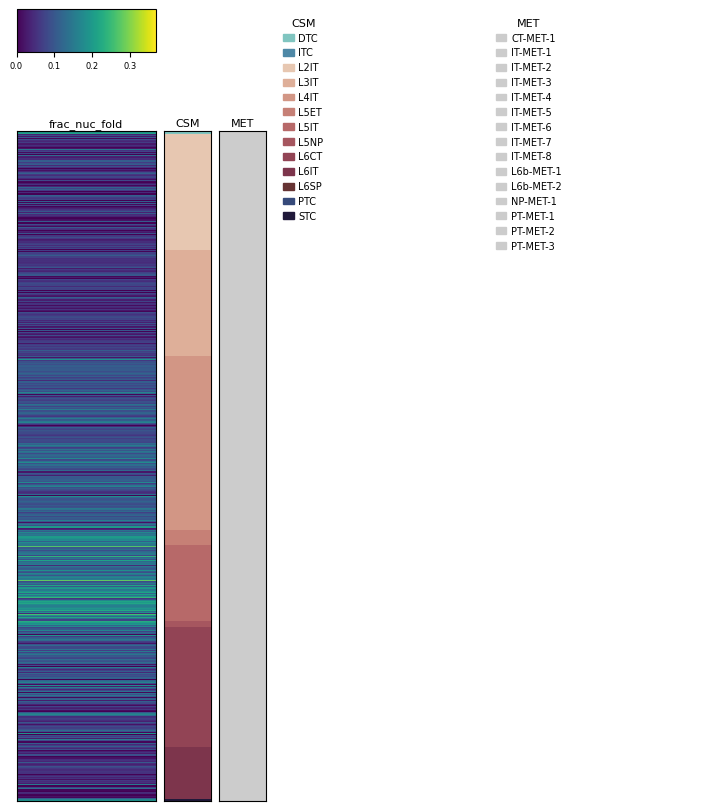

In [29]:
# Demo 1: 1 feature + CSM label + MET label, sorted by CSM then MET.
df_d1 = merge_strips("id",
    (feats_csm_df, ["fraction_nuclear_folding"]),
    (minnie_csm_df, ["predicted_label"], {"predicted_label": "csm_label"}),
    (em_exc_met_labels_df, ["predicted_label"], {"predicted_label": "met_label"}),
)
print(f"Demo 1: {len(df_d1):,} Minnie EXC cells")

fig = plot_strips(
    df_d1,
    features=[{"col": "fraction_nuclear_folding", "title": "frac_nuc_fold", "cmap": "viridis"}],
    labels=[
        {"col": "csm_label", "title": "CSM",  "colors": csm_colors},
        {"col": "met_label", "title": "MET",  "colors": met_colors},
    ],
    sort_by=["csm_label", "met_label"],
    colorbar_position="top",
)
plt.show()


*Look at how `fraction_nuclear_folding` varies within each CSM block. Within a CSM type, MET sub-blocks can show noticeably different feature values, hinting that MET type captures variation the CSM clustering alone doesn't resolve.*


### Demo 2 — Two Minnie features averaged by (CSM × MET) blocks

**What this shows:** The same Minnie cells as Demo 1, now with two features (`fraction_nuclear_folding`, `syn_size_distribution_dendrite_p50`) and group-mean averaging applied within each (CSM × MET) block.

**Why it's interesting:** Block-averaging makes the cross-taxonomy structure visible — you can see whether CSM types and MET types carve up the same cells consistently or in ways that reveal different biology.

In [35]:
# Build df_d2 — Minnie EXC base frame with 2 features + CSM label + MET label.
# Reused by Demos 3, 4, and 5.
df_d2 = merge_strips("id",
    (feats_csm_df, ["fraction_nuclear_folding", "syn_size_distribution_dendrite_p50"]),
    (minnie_csm_df, ["predicted_label"], {"predicted_label": "csm_label"}),
    (em_exc_met_labels_df, ["predicted_label"], {"predicted_label": "met_label"}),
)
print(f"df_d2 (base for demos 2–5): {len(df_d2):,} cells")
df_d2.head(3)


df_d2 (base for demos 2–5): 23,325 cells


,syn_size_distribution_dendrite_p50,fraction_nuclear_folding,id,csm_label,met_label
0,4340,0.017687,485509,L2IT,IT-MET-1
1,4618,0.123807,263203,L4IT,IT-MET-2
2,5460,0.124294,456177,L3IT,IT-MET-3


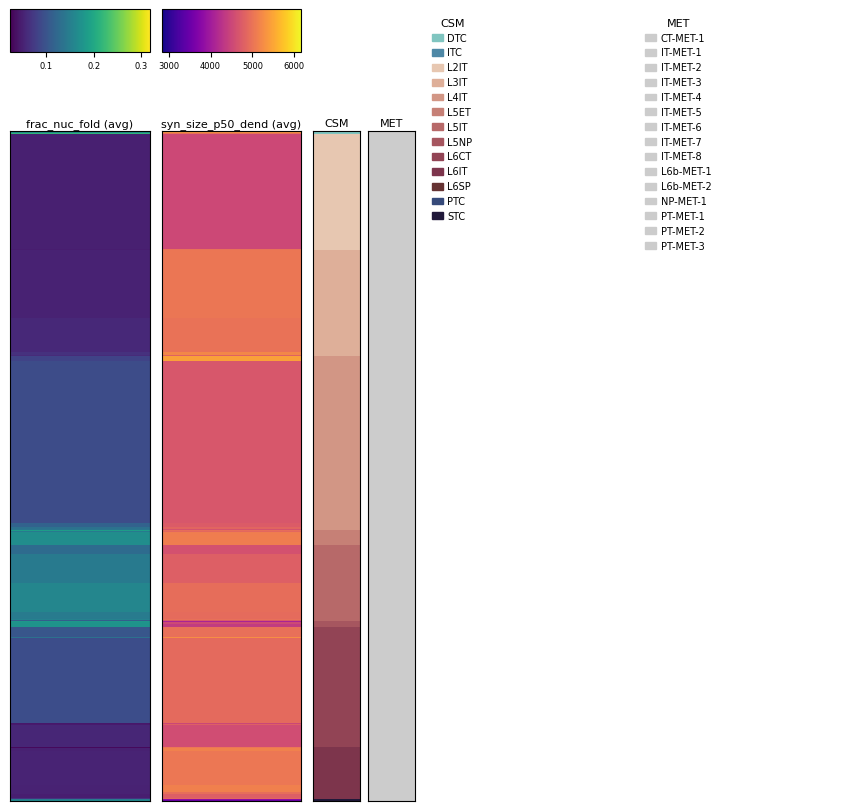

In [36]:
# Demo 2: averaged by (csm_label × met_label) block.
fig = plot_strips(
    df_d2,
    features=[
        {"col": "fraction_nuclear_folding",           "title": "frac_nuc_fold",    "cmap": "viridis"},
        {"col": "syn_size_distribution_dendrite_p50", "title": "syn_size_p50_dend", "cmap": "plasma"},
    ],
    labels=[
        {"col": "csm_label", "title": "CSM", "colors": csm_colors},
        {"col": "met_label", "title": "MET", "colors": met_colors},
    ],
    sort_by=["csm_label", "met_label"],
    average_by=["csm_label", "met_label"],
    colorbar_position="top",
)
plt.show()


*Compare the block pattern across the two features — they don't always agree. Blocks that are similar in `frac_nuc_fold` but different in `syn_size_p50_dend` suggest those two features capture partially independent biology. The sorting (CSM primary, MET secondary) shows whether MET sub-groups are consistently ordered the same way within each CSM block.*


### Demo 3 — Minnie + Patchseq side-by-side via stretching (MET as bridge)

**What this shows:** Left side: Minnie features + CSM + MET. Right side: patchseq cells stretched to match Minnie MET-group row counts, showing patchseq MET and T-type labels.

**Why it's interesting:** When both datasets share a cluster label (MET type), we can use that label as the bridge for visual alignment — even though the actual feature columns are disjoint. This is the simplest form of cross-modal comparison the schema enables.

In [37]:
# Build patchseq base frame: MET + T-type labels, sorted.
df_d3 = merge_strips("id",
    (patchseq_met_exc_df, ["predicted_label"], {"predicted_label": "met_label"}),
    (patchseq_ttype_exc_df, ["predicted_label"], {"predicted_label": "ttype_label"}),
)

# Restrict to MET types present in BOTH datasets; sort Minnie cells by met→csm.
df_left = df_d2.sort_values(["met_label", "csm_label"]).reset_index(drop=True)
df_right_base = df_d3.sort_values(["met_label", "ttype_label"]).reset_index(drop=True)
common_met = sorted(set(df_left["met_label"]) & set(df_right_base["met_label"]))
df_left       = df_left[df_left["met_label"].isin(common_met)].reset_index(drop=True)
df_right_base = df_right_base[df_right_base["met_label"].isin(common_met)].reset_index(drop=True)
print(f"Common MET types: {len(common_met)}  |  Minnie cells: {len(df_left):,}  |  Patchseq cells: {len(df_right_base):,}")

# Stretch patchseq to match Minnie row counts per MET group, then column-concat.
df_right = stretch_to_match(df_right_base, df_left, group_col="met_label")
df_demo3 = pd.concat(
    [df_left.reset_index(drop=True),
     df_right[["ttype_label"]].reset_index(drop=True)],
    axis=1,
)
print(f"df_demo3: {len(df_demo3):,} rows")


Common MET types: 0  |  Minnie cells: 0  |  Patchseq cells: 0


ValueError: No objects to concatenate

/tmp/ipykernel_109/537652554.py:188: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df[all_avg_cols] = df.groupby(average_by)[all_avg_cols].transform("mean")


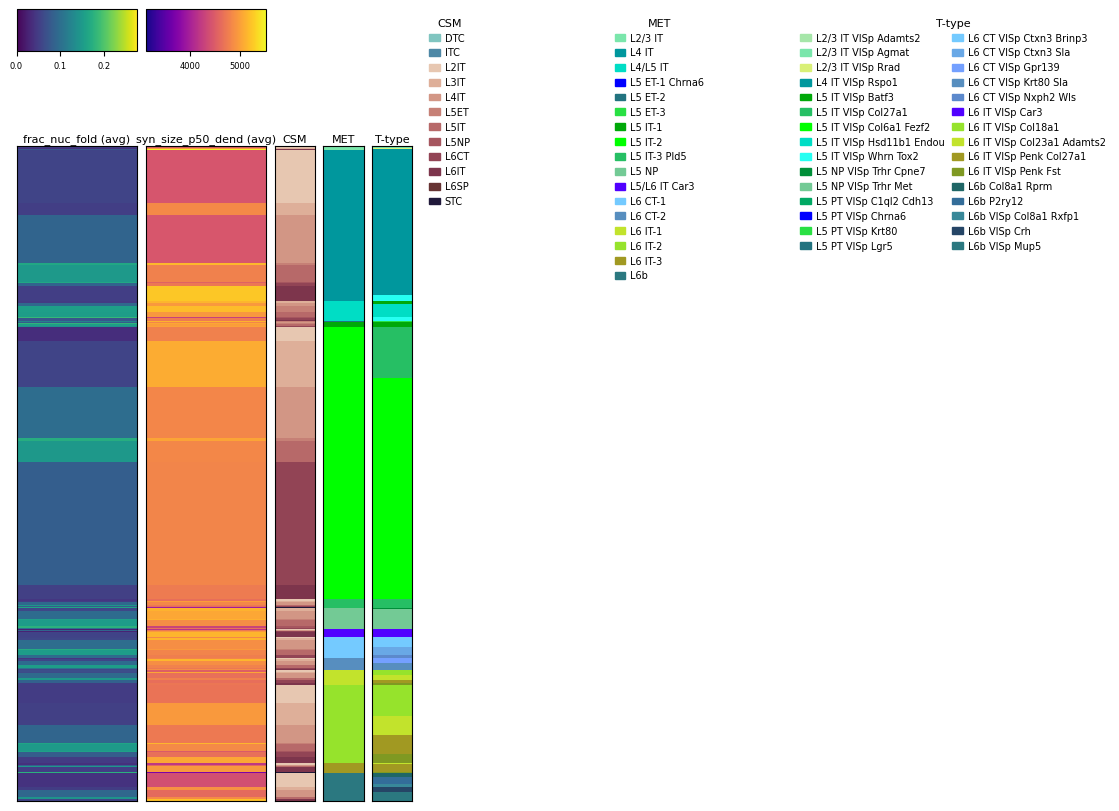

In [38]:
# Demo 3 plot: Minnie features + CSM + MET (left) + patchseq T-type (right).
fig = plot_strips(
    df_demo3,
    features=[
        {"col": "fraction_nuclear_folding",           "title": "frac_nuc_fold",    "cmap": "viridis"},
        {"col": "syn_size_distribution_dendrite_p50", "title": "syn_size_p50_dend", "cmap": "plasma"},
    ],
    labels=[
        {"col": "csm_label",   "title": "CSM",    "colors": csm_colors},
        {"col": "met_label",   "title": "MET",    "colors": met_colors},
        {"col": "ttype_label", "title": "T-type", "colors": ttype_colors},
    ],
    sort_by=["met_label", "csm_label"],
    average_by=["met_label", "csm_label"],
    colorbar_position="top",
)
plt.show()


*The T-type strip (rightmost) is stretched patchseq, aligned to Minnie's MET blocks. Within each MET block, look for T-type sub-structure: if a MET type maps cleanly to one T-type, the strip will be mostly one color. Noisy blocks suggest MET and T-type disagree on cell identity for that subgroup.*


### Demo 4 — Minnie + WNM side-by-side via stretching (same bridge, new modality)

**What this shows:** Left side: the same Minnie frame (features + CSM + MET). Right side: WNM cells stretched to match Minnie MET-group counts, showing three WNM-only axon morphology features (`axon_max_path_distance`, `axon_max_euclidean_distance`, `axon_num_branches`) from the new `wnm_csv_axon_feats_df`.

**Why it's interesting:** The same MET-bridging idea extends naturally to a third modality that has completely different features available. The `strips=` API allows the WNM features to appear after the label columns, aligned to the same MET blocks.

In [33]:
# Build WNM base frame: 3 axon features + WNM MET label (from new CSV).
_WNM_FEATS = ["axon_max_path_distance", "axon_max_euclidean_distance", "axon_num_branches"]
df_wnm_base = merge_strips("id",
    (wnm_csv_axon_feats_df, _WNM_FEATS),
    (wnm_met_df, ["predicted_label"], {"predicted_label": "met_label"}),
)

df_left = df_d2.sort_values(["met_label", "csm_label"]).reset_index(drop=True)
df_right_base = df_wnm_base.sort_values(["met_label"]).reset_index(drop=True)
common_met_d4 = sorted(set(df_left["met_label"]) & set(df_right_base["met_label"]))
df_left       = df_left[df_left["met_label"].isin(common_met_d4)].reset_index(drop=True)
df_right_base = df_right_base[df_right_base["met_label"].isin(common_met_d4)].reset_index(drop=True)
print(f"Common MET types: {len(common_met_d4)}  |  Minnie cells: {len(df_left):,}  |  WNM cells: {len(df_right_base):,}")

df_right = stretch_to_match(df_right_base, df_left, group_col="met_label")
df_demo4 = pd.concat(
    [df_left.reset_index(drop=True),
     df_right[_WNM_FEATS].reset_index(drop=True)],
    axis=1,
)
print(f"df_demo4: {len(df_demo4):,} rows")


Common MET types: 15  |  Minnie cells: 28,721  |  WNM cells: 341
df_demo4: 28,721 rows


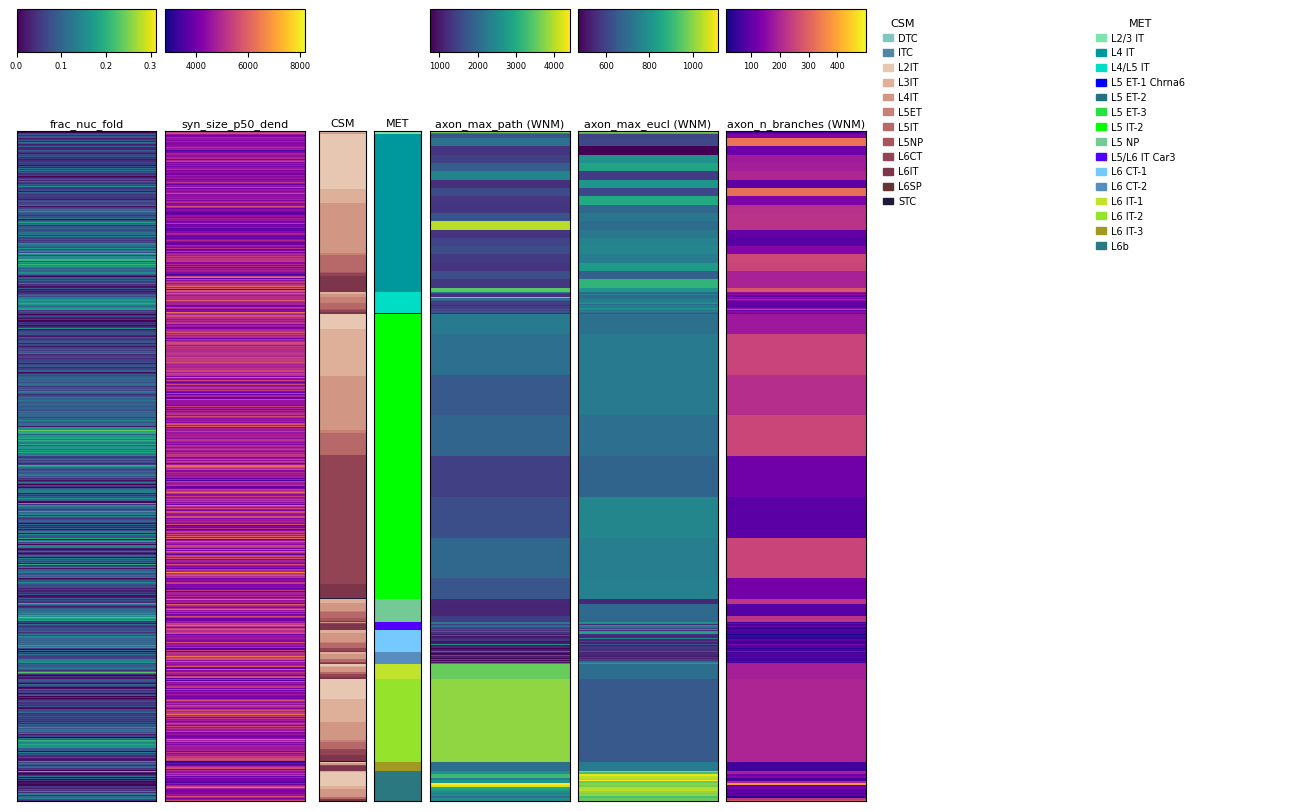

In [34]:
# Demo 4 plot: Minnie features + CSM + MET (left) + 3 WNM axon features (right).
fig = plot_strips(
    df_demo4,
    strips=[
        {"type": "feature", "col": "fraction_nuclear_folding",           "title": "frac_nuc_fold",          "cmap": "viridis"},
        {"type": "feature", "col": "syn_size_distribution_dendrite_p50", "title": "syn_size_p50_dend",       "cmap": "plasma"},
        {"type": "label",   "col": "csm_label",   "title": "CSM",   "colors": csm_colors},
        {"type": "label",   "col": "met_label",   "title": "MET",   "colors": met_colors},
        {"type": "feature", "col": "axon_max_path_distance",      "title": "axon_max_path (WNM)",      "cmap": "viridis"},
        {"type": "feature", "col": "axon_max_euclidean_distance", "title": "axon_max_eucl (WNM)",      "cmap": "viridis"},
        {"type": "feature", "col": "axon_num_branches",           "title": "axon_n_branches (WNM)",    "cmap": "plasma"},
    ],
    sort_by=["met_label", "csm_label"],
    colorbar_position="top",
)
plt.show()


*The three WNM axon feature columns (right) are aligned to the same MET blocks as the Minnie features. Look for whether `axon_max_path_distance` and `axon_max_euclidean_distance` vary systematically with MET type — long-range axon projectors tend to cluster in specific MET types. `axon_num_branches` adds a complementary view of axon complexity.*

### Demo 5 — Minnie + Patchseq via cell-to-cell mapping (bridging by cell identity)

**What this shows:** Each Minnie cell is directly paired with its single nearest patchseq neighbor (k=1 from the UMAP+kNN cell-to-cell mapping), and both modalities' labels appear as strips on the same row.

**Why it's interesting:** Instead of bridging by a shared cluster label (Demos 3 & 4), here we bridge by individual cell identity — a fundamentally different (and stronger) claim about cross-modal correspondence. This is the visualization I most want feedback on.

In [21]:
# Build df_d5: each Minnie cell paired 1:1 with its nearest patchseq neighbor (k=1).
K_NEIGHBOR = 1

df_ps = lookup_patchseq_neighbors(
    minnie_ctc_exc_df,
    patchseq_met_exc_df,
    patchseq_ttype_exc_df,
    k=K_NEIGHBOR,
)

df_d5 = df_d2.merge(df_ps[["id", "ps_met_label", "ps_ttype_label"]], on="id", how="inner")
df_d5 = df_d5.sort_values(["csm_label", "met_label"]).reset_index(drop=True)
print(f"Demo 5 (cell-to-cell, k={K_NEIGHBOR}): {len(df_d5):,} cells")
df_d5.head(3)


Demo 5 (cell-to-cell, k=1): 29,322 cells


,id,syn_size_distribution_dendrite_p50,fraction_nuclear_folding,csm_label,met_label,ps_met_label,ps_ttype_label
0,432518,4372,0.164120,DTC,L4 IT,L4 IT,L4 IT VISp Rspo1
1,232201,5068,0.174861,DTC,L4 IT,L4 IT,L4 IT VISp Rspo1
2,467775,4900,0.226894,DTC,L4 IT,L4 IT,L4 IT VISp Rspo1


**About the cell-to-cell mapping:** Each Minnie cell has an ordered list of nearest patchseq neighbors with UMAP distances, stored in a `CellToCellMapping`-shaped table produced by `yy07_12`. The neighbors were found by running supervised UMAP on the shared morphology feature space (Minnie skeleton-key features aligned to patchseq morph features) and then kNN lookup. In this version of the demo we show only the single closest neighbor (k=1). We will later want to also show k=2 and k=3 — and decide how to handle cases where those neighbors have different MET labels.

/tmp/ipykernel_18620/537652554.py:188: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df[all_avg_cols] = df.groupby(average_by)[all_avg_cols].transform("mean")


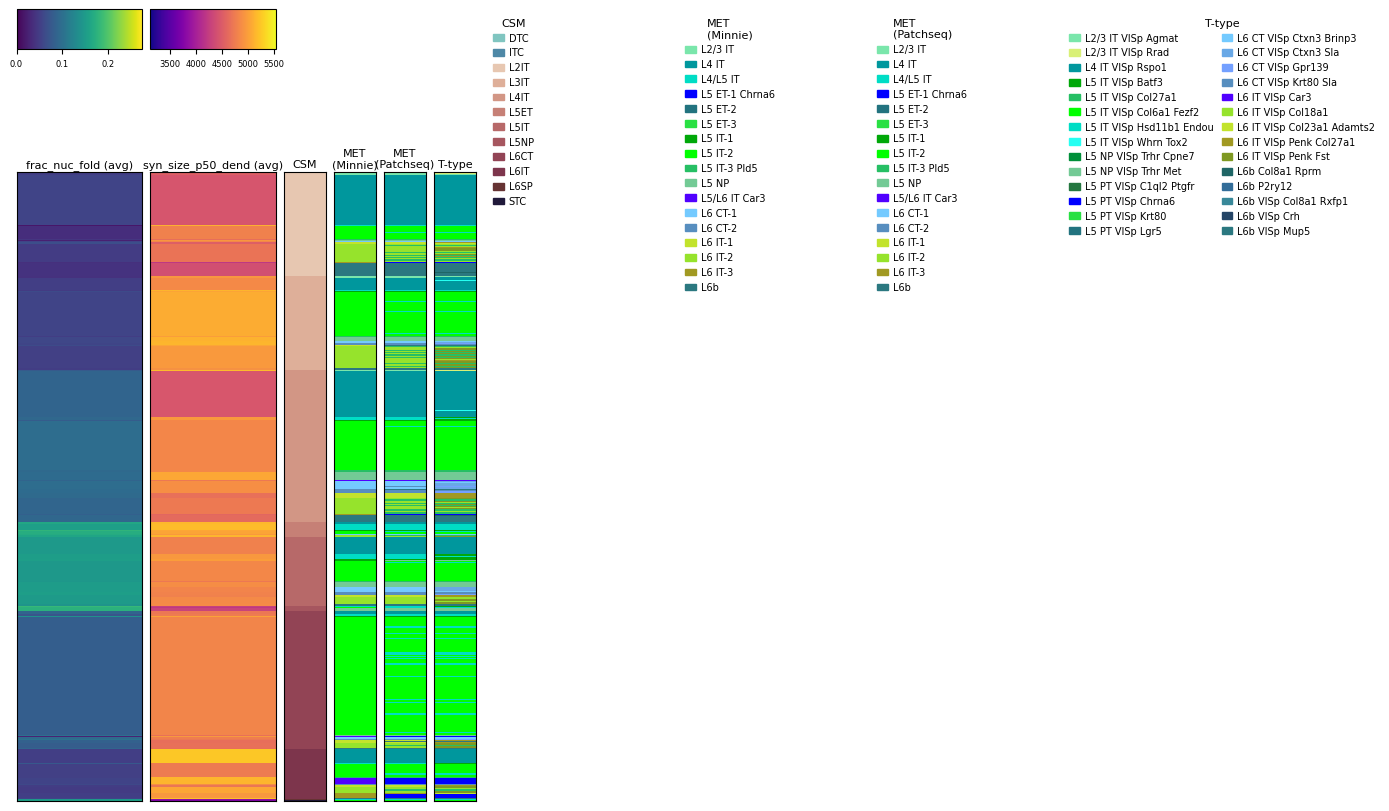

In [22]:
# Demo 5 plot: Minnie features (avg) + CSM + Minnie MET + Patchseq-neighbor MET + T-type.
fig = plot_strips(
    df_d5,
    features=[
        {"col": "fraction_nuclear_folding",           "title": "frac_nuc_fold",     "cmap": "viridis"},
        {"col": "syn_size_distribution_dendrite_p50", "title": "syn_size_p50_dend", "cmap": "plasma"},
    ],
    labels=[
        {"col": "csm_label",      "title": "CSM",              "colors": csm_colors},
        {"col": "met_label",      "title": "MET\n(Minnie)",    "colors": met_colors},
        {"col": "ps_met_label",   "title": "MET\n(Patchseq)",  "colors": met_colors},
        {"col": "ps_ttype_label", "title": "T-type",           "colors": ttype_colors},
    ],
    sort_by=["csm_label", "met_label"],
    average_by=["csm_label", "met_label"],
    colorbar_position="top",
)
plt.show()


*Compare the "MET (Minnie)" and "MET (Patchseq)" strips — cells where both strips are the same color are cases where the transferred label and the direct mapping agree. Discordant cells (different colors) are the most interesting: are they a UMAP artifact, a genuine biological ambiguity, or a labeling inconsistency? The T-type strip gives a third anchor for those cases.*
